# Illustrative control–capability trade-off

All 14 values are illustrative placeholders, not experimental results. One panel compares steering performance against capability loss relative to Unsteered (39.300). The horizontal axis uses a symmetric logarithmic scale, linear within 0.1 points of zero. Smaller loss is better; marker area encodes steering strength. Original data values are unchanged.

Run from the repository or `notebooks/`; export PDF first and show an SVG preview.


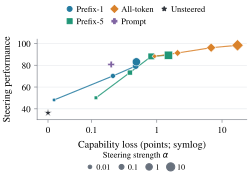

Saved illustrative figure: /home/xzascc/Documents/code/Prefix/figs/steering_tradeoff_7b_toy.pdf


In [1]:
from pathlib import Path
from io import StringIO
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator
from IPython.display import SVG, display

DATA = [
    # series, strength, general ability, steering performance

    ("Prefix-1", 10,    38.813, 83.127),
    ("Prefix-1", 1,     38.824, 79.341),
    ("Prefix-1", 0.1,   39.087, 70.214),
    ("Prefix-1", 0.01,  39.286, 48.173),

    ("Prefix-5", 10,    37.791, 89.238),
    ("Prefix-5", 1,     38.476, 88.154),
    ("Prefix-5", 0.1,   38.914, 73.286),
    ("Prefix-5", 0.01,  39.183, 50.127),

    ("All-token", 10,   22.042, 98.317),
    ("All-token", 1,    32.487, 96.124),
    ("All-token", 0.1,  37.216, 91.283),
    ("All-token", 0.01, 38.374, 88.195),

    ("Prompt", None,    39.100, 80.733),
    ("Unsteered", None, 39.300, 36.271),
]

STYLES = {
    "Prefix-1": {"color": "#247BA0", "marker": "o"},
    "Prefix-5": {"color": "#209677", "marker": "s"},
    "All-token": {"color": "#D9822B", "marker": "D"},
    "Prompt": {"color": "#8064A2", "marker": "P"},
    "Unsteered": {"color": "#30343B", "marker": "*"},
}
STRENGTH_SIZES = {0.01: 13, 0.1: 25, 1: 43, 10: 67}
BASELINE = next(row[2] for row in DATA if row[0] == "Unsteered")
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "notebooks").is_dir() and (p / "figs").is_dir())
OUTPUT = ROOT / "figs" / "steering_tradeoff_7b_toy.pdf"

with plt.rc_context({"font.family": "STIXGeneral", "pdf.fonttype": 42,
                     "font.size": 9, "axes.labelsize": 10,
                     "axes.edgecolor": "#727780", "axes.linewidth": 0.6}):
    fig, ax = plt.subplots(figsize=(3.6, 2.5))
    fig.subplots_adjust(left=0.16, right=0.97, bottom=0.32, top=0.77)
    for name, style in STYLES.items():
        points = sorted((r for r in DATA if r[0] == name),
                        key=lambda r: r[1] or -1)
        x = [BASELINE - r[2] for r in points]
        y = [r[3] for r in points]
        if len(points) > 1:
            ax.plot(x, y, color=style["color"], linewidth=1.15, alpha=0.85, zorder=2)
        sizes = [STRENGTH_SIZES[r[1]] if r[1] is not None
                 else (65 if name == "Unsteered" else 44) for r in points]
        ax.scatter(x, y, s=sizes, **style, edgecolors="white", linewidths=0.5, zorder=3)

    ax.set_xscale("symlog", linthresh=0.1, linscale=0.6)
    ax.set(xlim=(-0.025, 24), ylim=(30, 104), yticks=[40, 60, 80, 100])
    ticks = [0, 0.1, 1, 10]
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    ax.xaxis.set_major_formatter(FixedFormatter(["0", "0.1", "1", "10"]))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xlabel("Capability loss (points; symlog)", labelpad=5)
    ax.set_ylabel("Steering performance", labelpad=5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(length=3, width=0.6, color="#727780")
    ax.grid(axis="y", color="#E4E7EB", linewidth=0.55)
    ax.set_axisbelow(True)
    handles = [Line2D([], [], color=s["color"], marker=s["marker"],
                      linestyle="None", markersize=5, label=name)
               for name, s in STYLES.items()]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.54, 1.0),
               ncol=3, frameon=False, fontsize=8.5, columnspacing=0.8,
               handletextpad=0.35, handlelength=0.9, labelspacing=0.45)
    strength_handles = [Line2D([], [], marker="o", color="#68717D", linestyle="None",
                               markersize=size ** 0.5, label=f"{strength:g}")
                        for strength, size in STRENGTH_SIZES.items()]
    fig.legend(handles=strength_handles, title=r"Steering strength $\alpha$",
               loc="lower center", bbox_to_anchor=(0.54, -0.01), ncol=4,
               frameon=False, fontsize=8, title_fontsize=8.5,
               columnspacing=0.9, handletextpad=0.3, handlelength=1.0)
    fig.savefig(OUTPUT, format="pdf", bbox_inches="tight", pad_inches=0.03)
    preview = StringIO()
    fig.savefig(preview, format="svg", bbox_inches="tight", pad_inches=0.03)
    plt.close(fig)
    display(SVG(preview.getvalue()))

print(f"Saved illustrative figure: {OUTPUT}")
